In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\irene\OneDrive\Υπολογιστής\TuE\BEP\Code\Bachelor-End-Project-Code---XAI\data\german.csv")
df.head()

,Creditability,Account Balance,Duration of Credit (month),Payment Status of Previous Credit,Purpose,Credit Amount,Value Savings/Stocks,Length of current employment,Instalment per cent,Sex & Marital Status,...,Duration in Current address,Most valuable available asset,Age (years),Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2


In [3]:
df.keys()

Index(['Creditability', 'Account Balance', 'Duration of Credit (month)',
       'Payment Status of Previous Credit', 'Purpose', 'Credit Amount',
       'Value Savings/Stocks', 'Length of current employment',
       'Instalment per cent', 'Sex & Marital Status', 'Guarantors',
       'Duration in Current address', 'Most valuable available asset',
       'Age (years)', 'Concurrent Credits', 'Type of apartment',
       'No of Credits at this Bank', 'Occupation', 'No of dependents',
       'Telephone', 'Foreign Worker'],
      dtype='object')

In [4]:
df.describe()

,Creditability,Account Balance,Duration of Credit (month),Payment Status of Previous Credit,Purpose,Credit Amount,Value Savings/Stocks,Length of current employment,Instalment per cent,Sex & Marital Status,...,Duration in Current address,Most valuable available asset,Age (years),Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.700000,2.577000,20.903000,2.54500,2.828000,3271.24800,2.105000,3.384000,2.973000,2.68200,...,2.845000,2.358000,35.54200,2.675000,1.928000,1.407000,2.904000,1.155000,1.404000,1.037000
std,0.458487,1.257638,12.058814,1.08312,2.744439,2822.75176,1.580023,1.208306,1.118715,0.70808,...,1.103718,1.050209,11.35267,0.705601,0.530186,0.577654,0.653614,0.362086,0.490943,0.188856
min,0.000000,1.000000,4.000000,0.00000,0.000000,250.00000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,19.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,1.000000,12.000000,2.00000,1.000000,1365.50000,1.000000,3.000000,2.000000,2.00000,...,2.000000,1.000000,27.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
50%,1.000000,2.000000,18.000000,2.00000,2.000000,2319.50000,1.000000,3.000000,3.000000,3.00000,...,3.000000,2.000000,33.00000,3.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
75%,1.000000,4.000000,24.000000,4.00000,3.000000,3972.25000,3.000000,5.000000,4.000000,3.00000,...,4.000000,3.000000,42.00000,3.000000,2.000000,2.000000,3.000000,1.000000,2.000000,1.000000
max,1.000000,4.000000,72.000000,4.00000,10.000000,18424.00000,5.000000,5.000000,4.000000,4.00000,...,4.000000,4.000000,75.00000,3.000000,3.000000,4.000000,4.000000,2.000000,2.000000,2.000000


In [15]:
df.shape

(1000, 21)

## I will start with some basic cleaning checks to ensure the dataset is ready to be modeled

In [8]:
df.isnull().sum()

Creditability                        0
Account Balance                      0
Duration of Credit (month)           0
Payment Status of Previous Credit    0
Purpose                              0
Credit Amount                        0
Value Savings/Stocks                 0
Length of current employment         0
Instalment per cent                  0
Sex & Marital Status                 0
Guarantors                           0
Duration in Current address          0
Most valuable available asset        0
Age (years)                          0
Concurrent Credits                   0
Type of apartment                    0
No of Credits at this Bank           0
Occupation                           0
No of dependents                     0
Telephone                            0
Foreign Worker                       0
dtype: int64

In [13]:
# pandas encoded cat columns as int so we have to select them manually
numerical_cols = [
    'Duration of Credit (month)',
    'Credit Amount',
    'Instalment per cent',
    'Age (years)',
    'Duration in Current address',
    'No of Credits at this Bank',
    'No of dependents'
]

categorical_cols = [
    'Account Balance',
    'Payment Status of Previous Credit',
    'Purpose',
    'Value Savings/Stocks',
    'Length of current employment',
    'Sex & Marital Status',
    'Guarantors',
    'Most valuable available asset',
    'Concurrent Credits',
    'Type of apartment',
    'Occupation',
    'Telephone',
    'Foreign Worker'
]
target = 'Creditability'

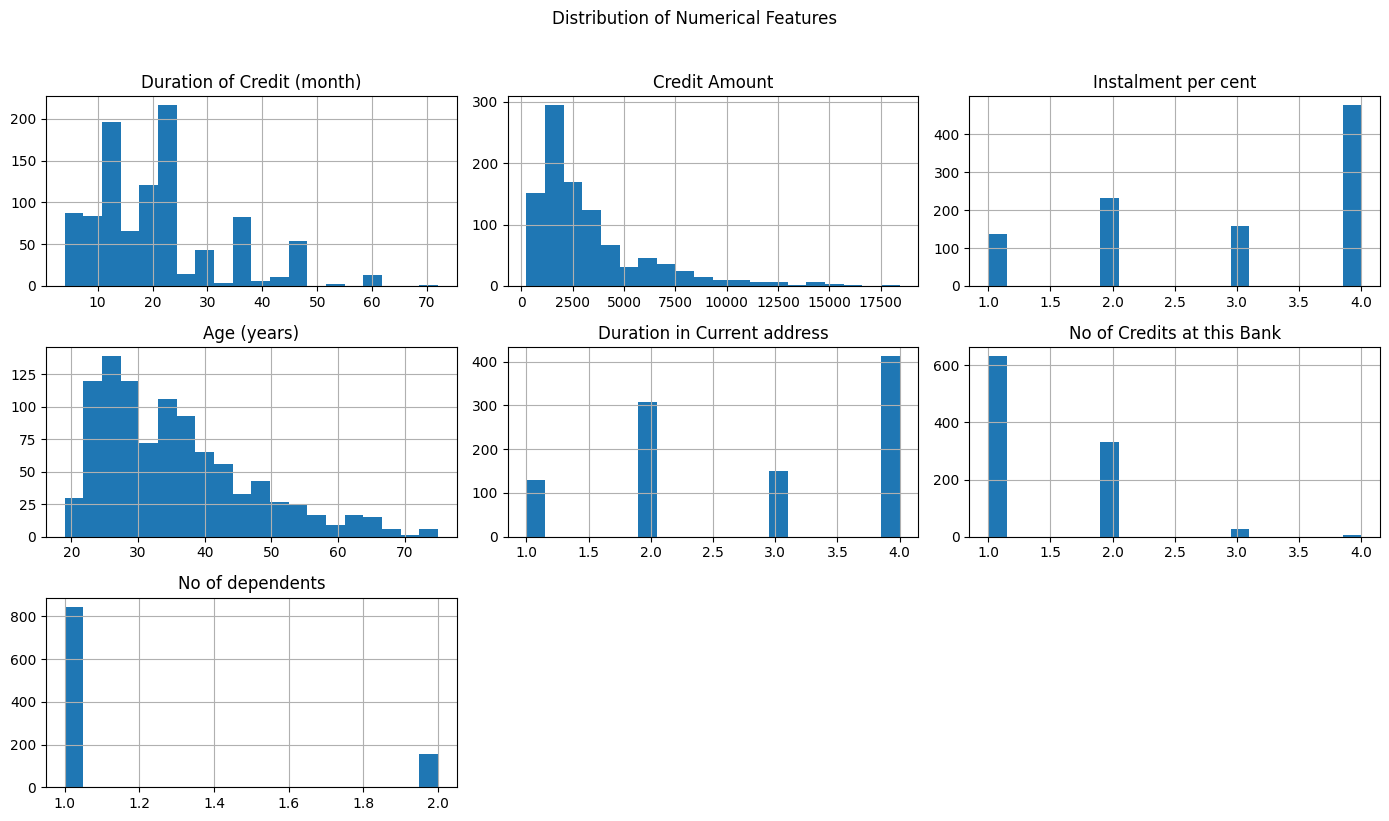

In [14]:
import matplotlib.pyplot as plt

df[numerical_cols].hist(figsize=(14,8), bins=20)

plt.suptitle("Distribution of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

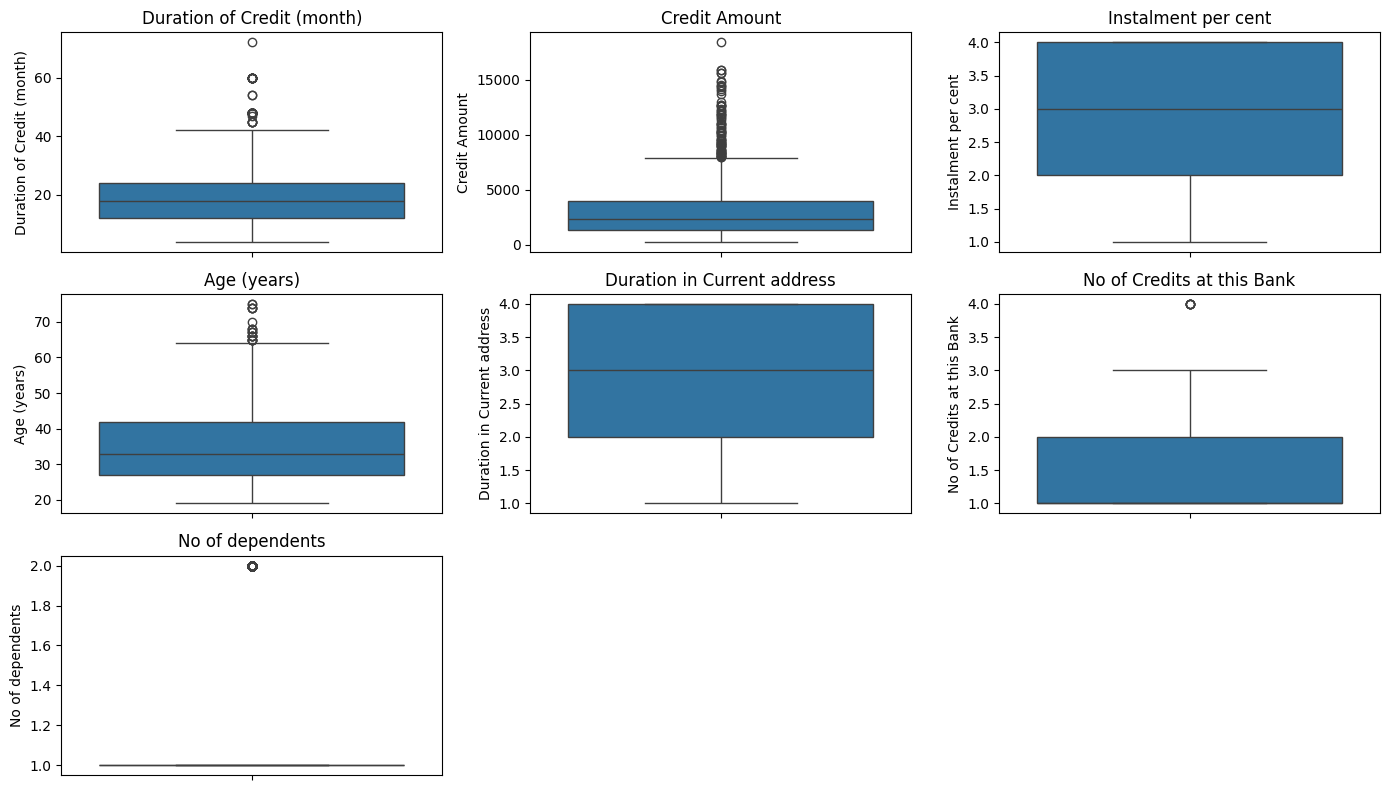

In [15]:
import seaborn as sns

plt.figure(figsize=(14,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

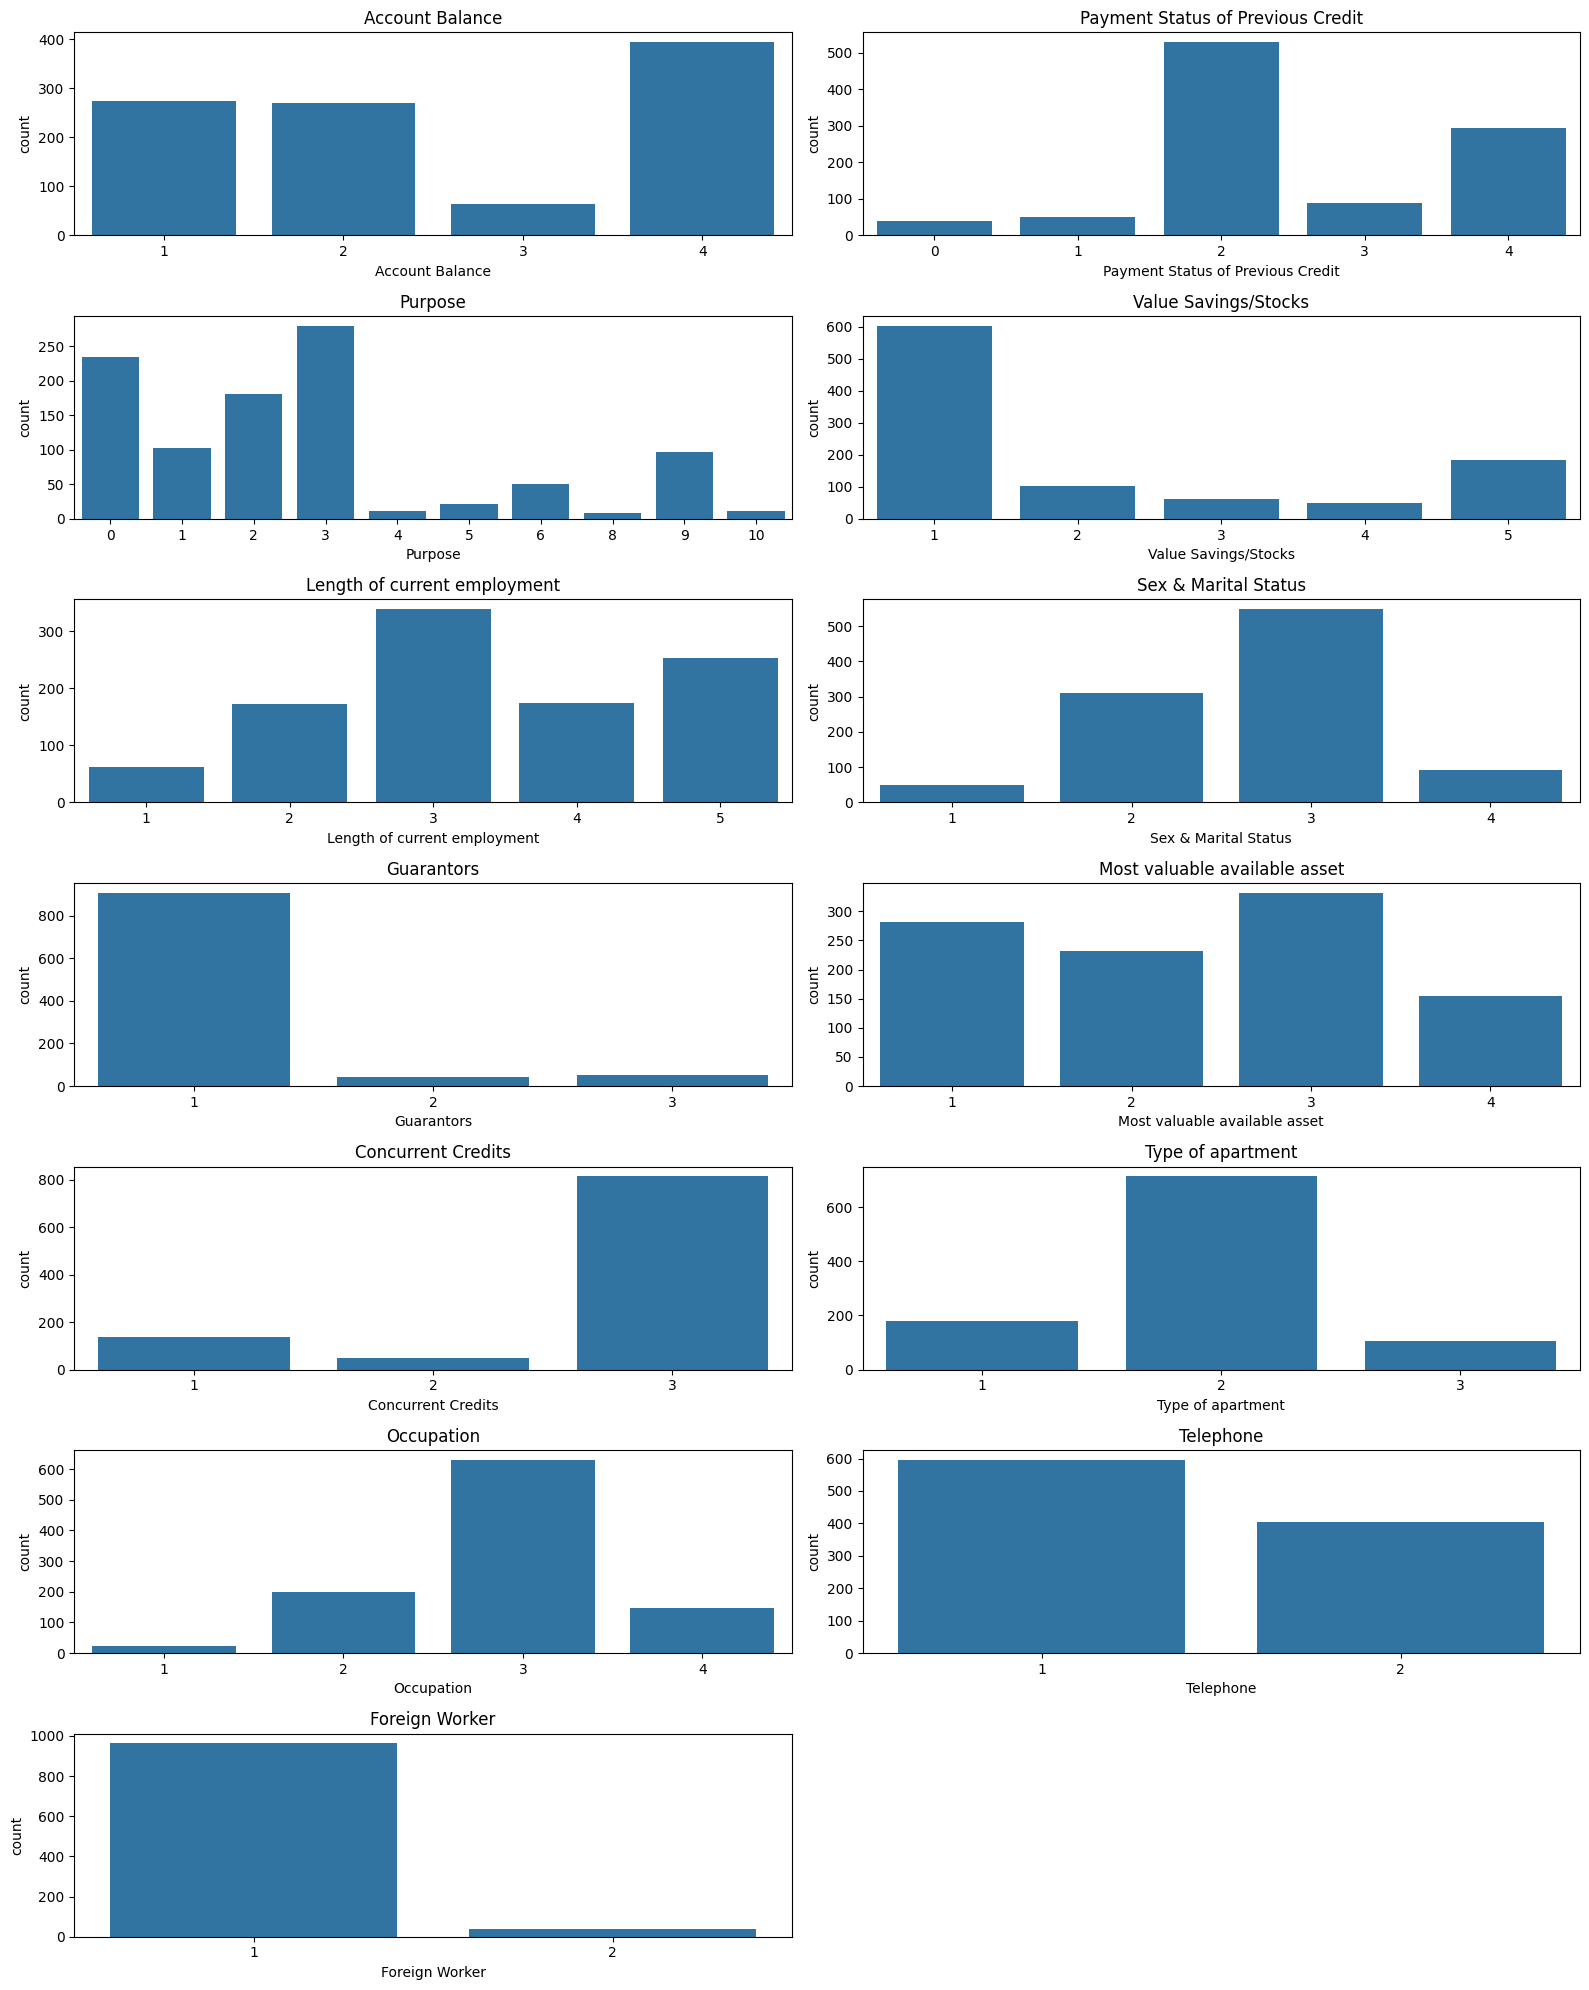

In [16]:
plt.figure(figsize=(16,20))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(7,2,i)
    sns.countplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

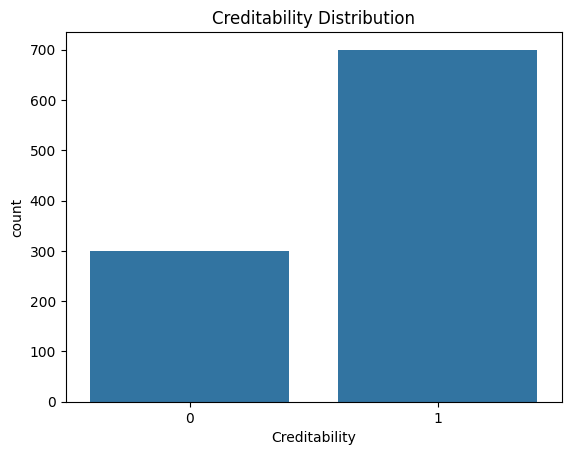

In [17]:
sns.countplot(x=df[target])
plt.title("Creditability Distribution")
plt.show()

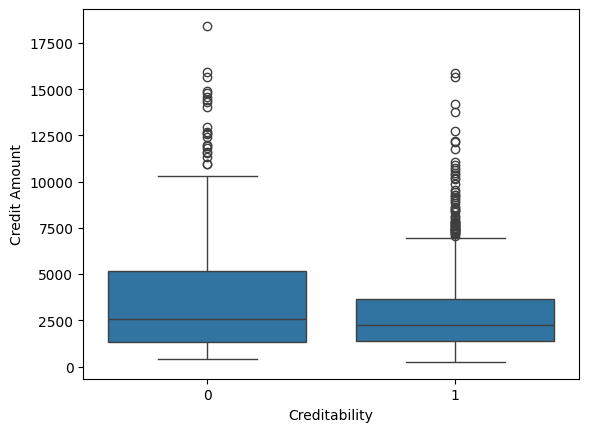

In [18]:
sns.boxplot(x=df[target], y=df['Credit Amount'])
plt.show()

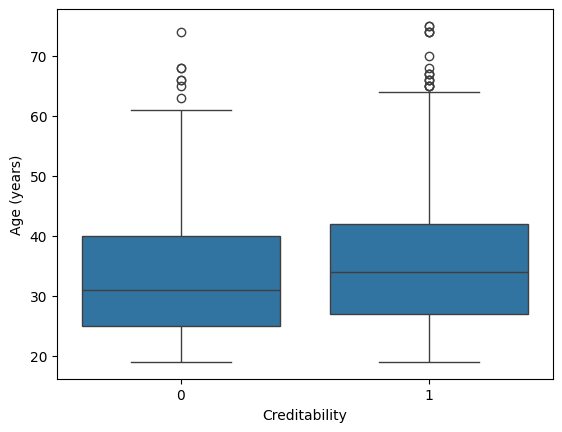

In [19]:
sns.boxplot(x=df[target], y=df['Age (years)'])
plt.show()

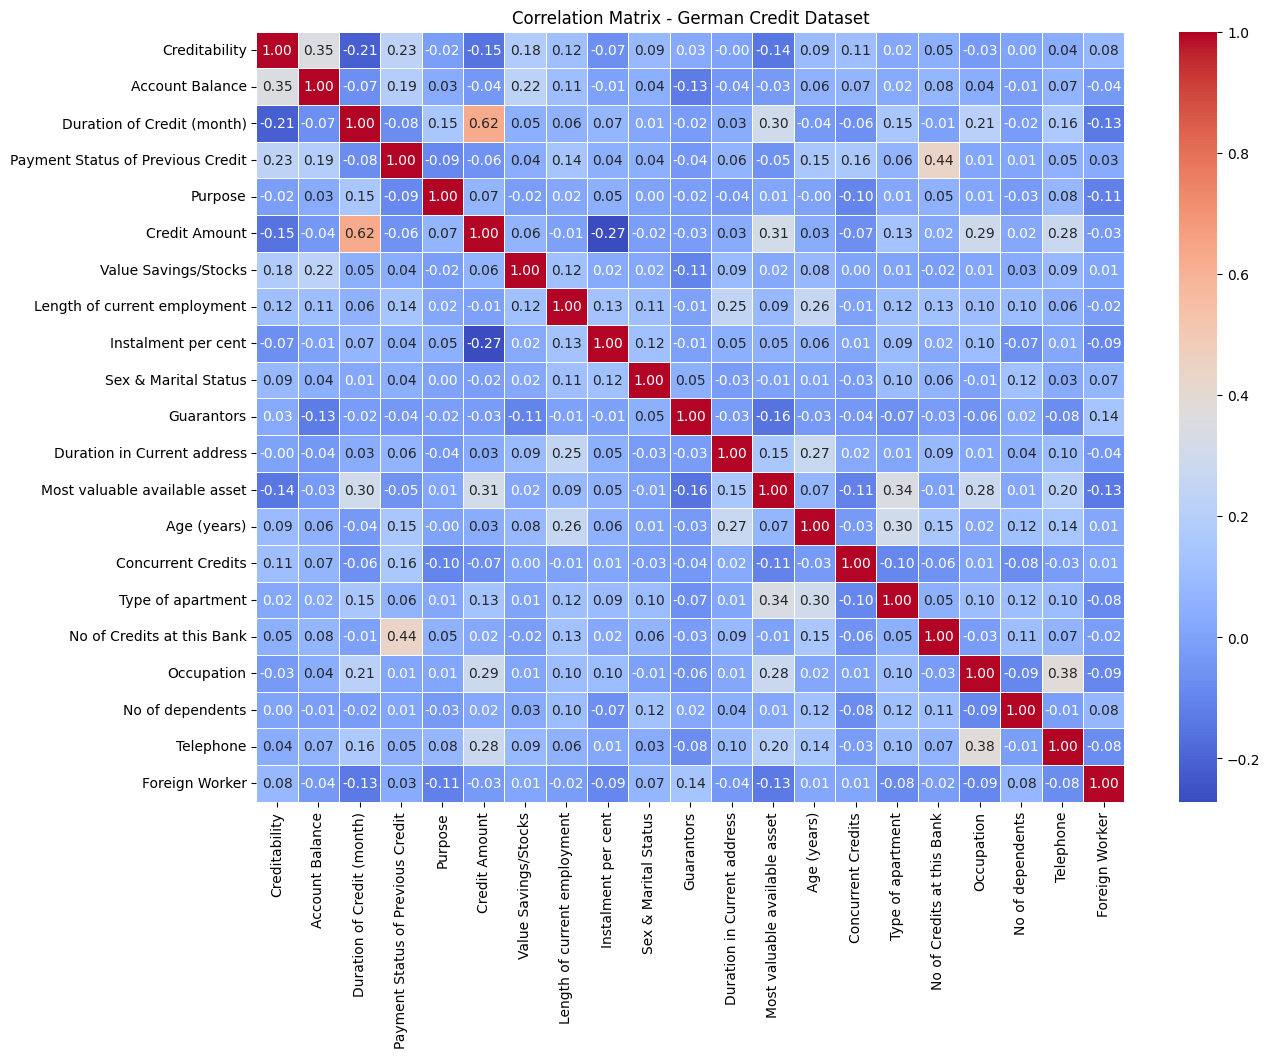

In [20]:

# compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix - German Credit Dataset")
plt.show()

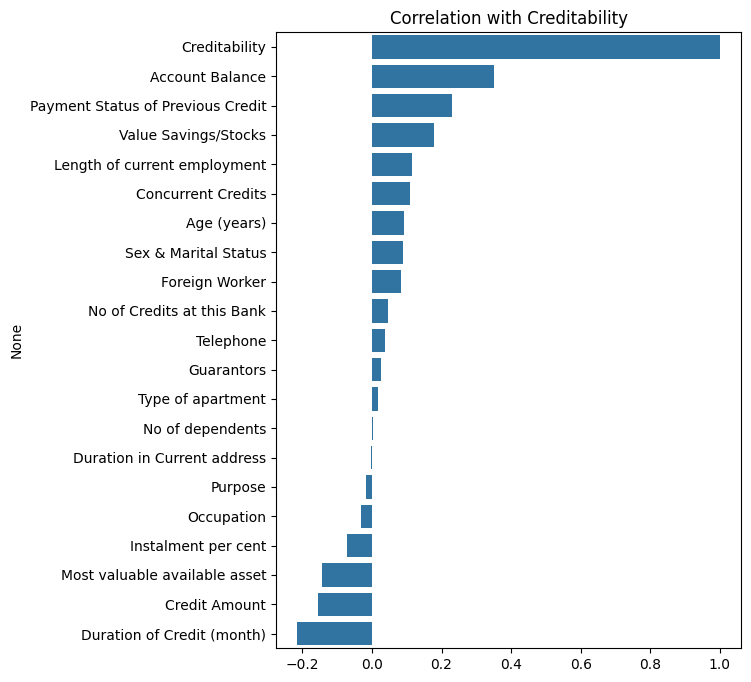

In [21]:
# focus on correlatiton with target
corr_target = df.corr(numeric_only=True)["Creditability"].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.barplot(x=corr_target.values, y=corr_target.index)

plt.title("Correlation with Creditability")
plt.show()